# Imja Lake moraine dam cumulative displacement time series data exploration
Quinn Brencher

In [15]:
import xarray as xr
import rasterio as rio
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import numpy as np

## Load polygon data

In [7]:
asc_burst = '012_023790_IW1'
des_burst = '121_258661_IW2'
dam_name = 'imja'
crs = 32645

In [3]:
## load polygons 

# read in dam polygon
dam_fn = f'../mapping/polygons/{dam_name}_md.shp'
dam_gdf = gpd.read_file(dam_fn)

# read in moving area polygon
moving_fn = f'../mapping/polygons/{dam_name}_moving.shp'
moving_gdf = gpd.read_file(moving_fn)

# read in reference area polygon
reference_fn = f'../mapping/polygons/{dam_name}_reference.shp'
reference_gdf = gpd.read_file(reference_fn)

# read in stable area polygon
stable_fn = f'../mapping/polygons/{dam_name}_stable.shp'
stable_gdf = gpd.read_file(stable_fn)

# read in water mask
water_fn = f'../mapping/polygons/water_mask.shp'
water_gdf = gpd.read_file(water_fn)

# pad dam bounds by 5 km to crop products
padding = 5000
aoi_extent = [dam_gdf.bounds.minx.item()-padding,
               dam_gdf.bounds.maxy.item()+padding,
               dam_gdf.bounds.maxx.item()+padding,
               dam_gdf.bounds.miny.item()-padding]

## Explore moraine dam InSAR coherence

In [9]:
# open as xarray dataset
asc_corr_ds = xr.open_dataset(f'data_release/ascending_{asc_burst}_coherence.nc').rio.write_crs(crs)
des_corr_ds = xr.open_dataset(f'data_release/descending_{des_burst}_coherence.nc').rio.write_crs(crs)

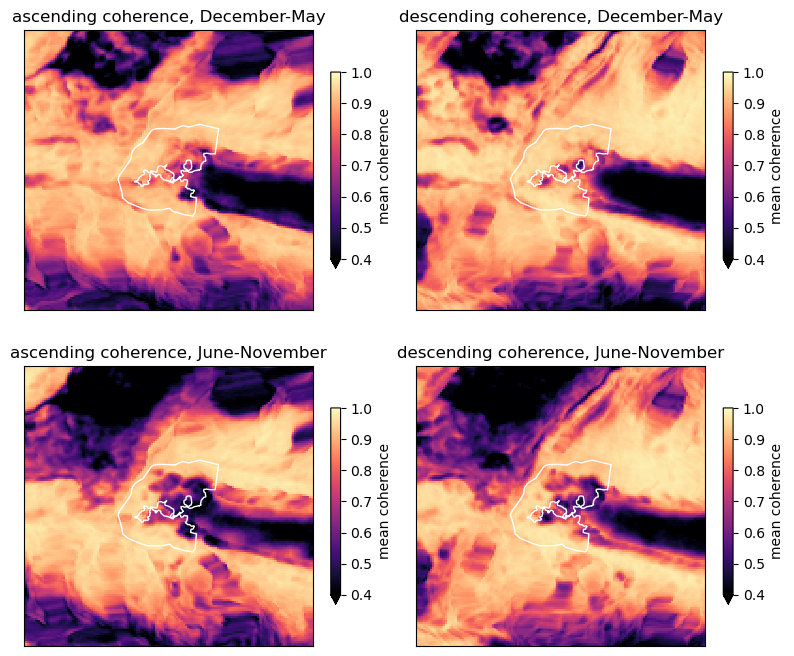

In [14]:
## plot mean summer and winter coherence for 12-day pairs

# isolate 12-day pairs
asc_corr_ds_12day = asc_corr_ds.where(asc_corr_ds.t_baseline.dt.days == 12 , drop=True)
des_corr_ds_12day = des_corr_ds.where(des_corr_ds.t_baseline.dt.days == 12 , drop=True)

# summer and non-summer coherence
asc_corr_summer_ds = asc_corr_ds_12day.where((asc_corr_ds_12day.start_date.dt.dayofyear > 152) & (asc_corr_ds_12day.end_date.dt.dayofyear < 334), drop=True)
des_corr_summer_ds = des_corr_ds_12day.where((des_corr_ds_12day.start_date.dt.dayofyear > 152) & (des_corr_ds_12day.end_date.dt.dayofyear < 334), drop=True)

asc_corr_winter_ds = asc_corr_ds_12day.where((asc_corr_ds_12day.start_date.dt.dayofyear < 152) | (asc_corr_ds_12day.end_date.dt.dayofyear > 334), drop=True)
des_corr_winter_ds = des_corr_ds_12day.where((des_corr_ds_12day.start_date.dt.dayofyear < 152) | (des_corr_ds_12day.end_date.dt.dayofyear > 334), drop=True)

# Set up figure and axes
f, ax = plt.subplots(2, 2, figsize=(8, 7), sharex=True, sharey=True)

# Helper function to plot a single panel
def plot_panel(data, axis, title):
    data.mean(dim='dates').plot.imshow(
        ax=axis,
        vmin=0.4,
        vmax=1,
        cmap='magma',
        cbar_kwargs={'label': 'mean coherence', 'shrink': 0.6}
    )
    dam_gdf.plot(ax=axis, edgecolor='white', facecolor='none')
    axis.set_title(title)
    axis.set_aspect('equal')
    padding = 4000
    axis.set_xlim(aoi_extent[0]+padding, aoi_extent[2]-padding)
    axis.set_ylim(aoi_extent[3]+padding, aoi_extent[1]-padding)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel('')
    axis.set_ylabel('')

# List of datasets, axes, and titles
panels = [
    (asc_corr_winter_ds, ax[0, 0], 'ascending coherence, December-May'),
    (des_corr_winter_ds, ax[0, 1], 'descending coherence, December-May'),
    (asc_corr_summer_ds, ax[1, 0], 'ascending coherence, June-November'),
    (des_corr_summer_ds, ax[1, 1], 'descending coherence, June-November'),
]

# Plot all panels
for ds, axis, title in panels:
    plot_panel(ds[f'corr_{dam_name}'], axis, title)

f.tight_layout()

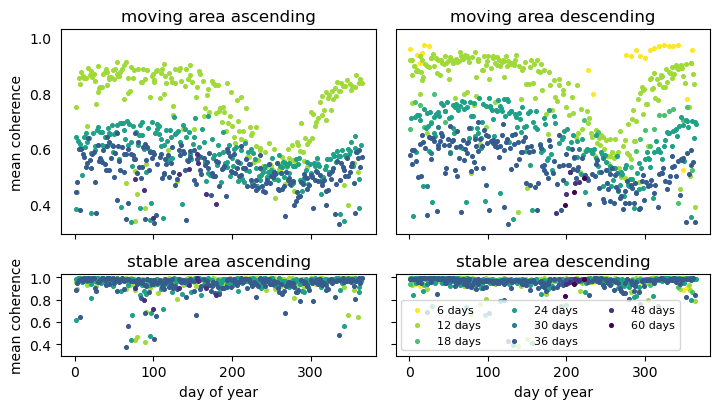

In [20]:
# plot seasonal coherence change over moving and stable area

# clip datasets to moving polygon
asc_dam_corr_ds = asc_corr_ds.rio.clip(moving_gdf.geometry.values, crs=moving_gdf.crs, drop=True)
asc_dam_corr_ds = asc_dam_corr_ds.assign_coords(middle_date = ('dates', (asc_dam_corr_ds.t_baseline/2+asc_dam_corr_ds.start_date).data))

des_dam_corr_ds = des_corr_ds.rio.clip(moving_gdf.geometry.values, crs=moving_gdf.crs, drop=True)
des_dam_corr_ds = des_dam_corr_ds.assign_coords(middle_date = ('dates', (des_dam_corr_ds.t_baseline/2+des_dam_corr_ds.start_date).data))

# clip datasets to stable polygon
asc_stable_corr_ds = asc_corr_ds.rio.clip(stable_gdf.geometry.values, crs=stable_gdf.crs, drop=True)
asc_stable_corr_ds = asc_stable_corr_ds.assign_coords(middle_date = ('dates', (asc_stable_corr_ds.t_baseline/2+asc_stable_corr_ds.start_date).data))

des_stable_corr_ds = des_corr_ds.rio.clip(stable_gdf.geometry.values, crs=stable_gdf.crs, drop=True)
des_stable_corr_ds = des_stable_corr_ds.assign_coords(middle_date = ('dates', (des_stable_corr_ds.t_baseline/2+des_stable_corr_ds.start_date).data))

t_baselines = np.union1d(des_dam_corr_ds.t_baseline.dt.days.values, asc_dam_corr_ds.t_baseline.dt.days.values)

# plot seasonal changes in coherence 
colors = plt.cm.viridis_r(np.linspace(0, 1, len(t_baselines)))

f, ax = plt.subplots(2, 2, figsize=(7.5, 4.2), sharex=True, sharey=True, gridspec_kw={'height_ratios': [2.5, 1]})
for i, days in enumerate(t_baselines):       
        
        ax[0, 0].scatter(asc_dam_corr_ds.middle_date[asc_dam_corr_ds.t_baseline.dt.days == days].dt.dayofyear,
                      asc_dam_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[asc_dam_corr_ds.t_baseline.dt.days == days],
                      color=colors[i],
                      s=7,
                      label=f'{int(days)} days')
        ax[0, 0].tick_params(left=False)

        ax[0, 1].scatter(des_dam_corr_ds.middle_date[des_dam_corr_ds.t_baseline.dt.days == days].dt.dayofyear,
                      des_dam_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[des_dam_corr_ds.t_baseline.dt.days == days],
                      color=colors[i],
                      s=7,
                      label=f'{int(days)} days')
        ax[0, 1].tick_params(left=False)

        ax[1, 0].scatter(asc_stable_corr_ds.middle_date[asc_stable_corr_ds.t_baseline.dt.days == days].dt.dayofyear,
                      asc_stable_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[asc_stable_corr_ds.t_baseline.dt.days == days],
                      color=colors[i],
                      s=7,
                      label=f'{int(days)} days')

        ax[1, 1].scatter(des_stable_corr_ds.middle_date[des_stable_corr_ds.t_baseline.dt.days == days].dt.dayofyear,
                      des_stable_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[des_stable_corr_ds.t_baseline.dt.days == days],
                      color=colors[i],
                      s=7,
                      label=f'{int(days)} days')

        ax[0, 0].set_ylabel('mean coherence')
        ax[1, 0].set_ylabel('mean coherence')
        ax[1, 0].set_xlabel('day of year')
        ax[1, 1].set_xlabel('day of year')
        ax[0, 0].set_title('moving area ascending')
        ax[0, 1].set_title('moving area descending')
        ax[1, 0].set_title('stable area ascending')
        ax[1, 1].set_title('stable area descending')
        ax[1, 1].legend(loc='lower left', fontsize=8, ncol=3)
  
f.tight_layout()

(3085224.5274983225, 3087199.4173047645)

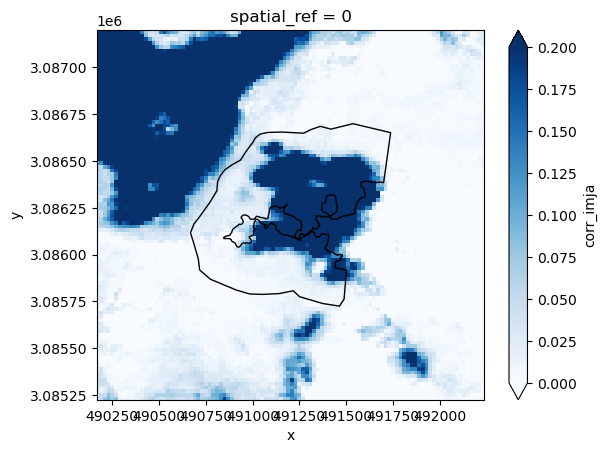

In [26]:
## buried ice extent

# low-coherence period 
asc_lowcorr_ds = asc_corr_ds_12day.where((asc_corr_ds_12day.start_date.dt.dayofyear > 220) & (asc_corr_ds_12day.end_date.dt.dayofyear < 280), drop=True)
des_lowcorr_ds = des_corr_ds_12day.where((des_corr_ds_12day.start_date.dt.dayofyear > 220) & (des_corr_ds_12day.end_date.dt.dayofyear < 280), drop=True)

# high-coherence period
asc_highcorr_ds = asc_corr_ds_12day.where(asc_corr_ds_12day.start_date.dt.dayofyear < 100, drop=True)
des_highcorr_ds = des_corr_ds_12day.where(des_corr_ds_12day.start_date.dt.dayofyear < 100, drop=True)

# combined coherence
asc_lowcorr_da = asc_lowcorr_ds.median(dim='dates').corr_imja
des_lowcorr_da = des_lowcorr_ds.median(dim='dates').corr_imja
lowcorr_da = (asc_lowcorr_da + des_lowcorr_da)/2

asc_highcorr_da = asc_highcorr_ds.median(dim='dates').corr_imja
des_highcorr_da = des_highcorr_ds.median(dim='dates').corr_imja
highcorr_da = (asc_highcorr_da + des_highcorr_da)/2

f, ax = plt.subplots()
(highcorr_da - lowcorr_da).plot(ax=ax, vmin=0, vmax=0.2, cmap='Blues')
dam_gdf.plot(ax=ax, edgecolor='black', facecolor='none')
padding=4500
ax.set_xlim(aoi_extent[0]+padding, aoi_extent[2]-padding)
ax.set_ylim(aoi_extent[3]+padding, aoi_extent[1]-padding)
ax.set_title('buried ice extent')

## Explore moraine dam displacement time series